In [1]:
# %%
import sys
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
# %%
PROJECT_ROOT = r"D:\XO06_DS02"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: D:\XO06_DS02


In [3]:
# %%
from src.feature_engineering import (
    create_temporal_features,
    create_relationship_features
)

print("✅ Feature engineering functions loaded")

✅ Feature engineering functions loaded


In [4]:
# %%
TRAIN_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "development_train.csv"
)

df = pd.read_csv(TRAIN_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (9800, 8)


,Station_ID,Timestamp,CO_Channel,NOx_Channel,NO2_Channel,Ambient_Temperature,Relative_Humidity,Absolute_Humidity
0,STN-01,01-01-2021 00:00,1.2,411.0,157.0,4.8,56.3,0.9245
1,STN-01,01-01-2021 01:00,1.5,397.0,167.0,2.9,54.7,0.8249
2,STN-01,01-01-2021 02:00,0.7,300.0,135.0,1.8,50.1,0.7405
3,STN-01,01-01-2021 03:00,0.5,284.0,142.0,0.9,48.8,0.6769
4,STN-01,01-01-2021 04:00,0.0,209.0,118.0,0.9,53.6,0.7118


In [5]:
# %%
print(df.columns.tolist())

['Station_ID', 'Timestamp', 'CO_Channel', 'NOx_Channel', 'NO2_Channel', 'Ambient_Temperature', 'Relative_Humidity', 'Absolute_Humidity']


In [6]:
# %%
SENSOR_COLS = [
     "CO_Channel",
    "NOx_Channel",
    "NO2_Channel",
    "Ambient_Temperature",
    "Relative_Humidity",
    "Absolute_Humidity"
]

print("Sensors:", SENSOR_COLS)

Sensors: ['CO_Channel', 'NOx_Channel', 'NO2_Channel', 'Ambient_Temperature', 'Relative_Humidity', 'Absolute_Humidity']


In [7]:
# %%
df = create_temporal_features(
    df,
    sensor_columns=SENSOR_COLS,
    rolling_window=6
)

print("✅ Temporal features created")

print("New shape:", df.shape)

✅ Temporal features created
New shape: (9800, 39)


In [8]:
# %%
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (
        df.isna().mean() * 100
    )
})

missing_summary = (
    missing_summary
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

missing_summary

,Missing_Count,Missing_Percentage
NOx_Channel_ZScore,382,3.897959
CO_Channel_ZScore,355,3.622449
NO2_Channel_ZScore,306,3.122449
NO2_Channel_Deviation,294,3.000000
NO2_Channel,286,2.918367
NOx_Channel_Deviation,286,2.918367
NOx_Channel,278,2.836735
CO_Channel_Deviation,261,2.663265
CO_Channel,253,2.581633
Relative_Humidity_ZScore,241,2.459184


In [9]:
# %%
for sensor in SENSOR_COLS:

    q1 = df[sensor].quantile(0.25)
    q3 = df[sensor].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df[f"{sensor}_StatisticalAnomaly"] = (
        (df[sensor] < lower_bound)
        |
        (df[sensor] > upper_bound)
    ).astype(int)

print("✅ Statistical anomaly detection completed")

✅ Statistical anomaly detection completed


In [10]:
# %%
STATISTICAL_ANOMALY_COLS = [
    f"{sensor}_StatisticalAnomaly"
    for sensor in SENSOR_COLS
]

df["Statistical_Anomaly_Count"] = (
    df[STATISTICAL_ANOMALY_COLS]
    .sum(axis=1)
)

print(
    df["Statistical_Anomaly_Count"]
    .value_counts()
    .sort_index()
)

Statistical_Anomaly_Count
0    9506
1     283
2      11
Name: count, dtype: int64


In [11]:
# %%
TEMPORAL_ANOMALY_COLS = [
    f"{sensor}_TemporalAnomaly"
    for sensor in SENSOR_COLS
    if f"{sensor}_TemporalAnomaly" in df.columns
]

print(
    "Temporal anomaly columns:"
)

print(
    TEMPORAL_ANOMALY_COLS
)

Temporal anomaly columns:
['CO_Channel_TemporalAnomaly', 'NOx_Channel_TemporalAnomaly', 'NO2_Channel_TemporalAnomaly', 'Ambient_Temperature_TemporalAnomaly', 'Relative_Humidity_TemporalAnomaly', 'Absolute_Humidity_TemporalAnomaly']


In [12]:
# %%
print(
    df[
        [
            "Temporal_Anomaly_Count"
        ]
    ].describe()
)

       Temporal_Anomaly_Count
count                  9800.0
mean                      0.0
std                       0.0
min                       0.0
25%                       0.0
50%                       0.0
75%                       0.0
max                       0.0


In [13]:
# %%
def identify_affected_sensors(row):

    affected = []

    for sensor in SENSOR_COLS:

        statistical_col = (
            f"{sensor}_StatisticalAnomaly"
        )

        temporal_col = (
            f"{sensor}_TemporalAnomaly"
        )

        statistical_flag = row.get(
            statistical_col,
            0
        )

        temporal_flag = row.get(
            temporal_col,
            0
        )

        if (
            statistical_flag == 1
            or temporal_flag == 1
        ):
            affected.append(sensor)

    if len(affected) == 0:
        return "None"

    return ", ".join(affected)


df["Affected_Sensors"] = df.apply(
    identify_affected_sensors,
    axis=1
)

df[
    [
        "Affected_Sensors"
    ]
].head(20)

,Affected_Sensors
0,None
1,None
2,None
3,None
4,None
5,None
6,None
7,None
8,None
9,None


In [14]:
# %%
def identify_missing_sensors(row):

    missing = []

    for sensor in SENSOR_COLS:

        if pd.isna(row[sensor]):
            missing.append(sensor)

    if len(missing) == 0:
        return "None"

    return ", ".join(missing)


df["Missing_Sensors"] = df.apply(
    identify_missing_sensors,
    axis=1
)

df[
    [
        "Missing_Sensors"
    ]
].head(20)

,Missing_Sensors
0,None
1,None
2,None
3,None
4,None
5,None
6,None
7,None
8,None
9,None


In [15]:
# %%
df["Temporal_Reliability"] = (
    1
    -
    (
        df["Temporal_Anomaly_Count"]
        / len(SENSOR_COLS)
    )
).clip(0, 1)

df[
    [
        "Temporal_Anomaly_Count",
        "Temporal_Reliability"
    ]
].head(20)

,Temporal_Anomaly_Count,Temporal_Reliability
0,0,1.0
1,0,1.0
2,0,1.0
3,0,1.0
4,0,1.0
5,0,1.0
6,0,1.0
7,0,1.0
8,0,1.0
9,0,1.0


In [16]:
# %%
df["Statistical_Reliability"] = (
    1
    -
    (
        df["Statistical_Anomaly_Count"]
        / len(SENSOR_COLS)
    )
).clip(0, 1)

df[
    [
        "Statistical_Anomaly_Count",
        "Statistical_Reliability"
    ]
].head(20)

,Statistical_Anomaly_Count,Statistical_Reliability
0,0,1.0
1,0,1.0
2,0,1.0
3,0,1.0
4,0,1.0
5,0,1.0
6,0,1.0
7,0,1.0
8,0,1.0
9,0,1.0


In [17]:
# %%
df["Missing_Count"] = (
    df[SENSOR_COLS]
    .isna()
    .sum(axis=1)
)

df["Missing_Ratio"] = (
    df["Missing_Count"]
    / len(SENSOR_COLS)
)

df["Missingness_Reliability"] = (
    1 - df["Missing_Ratio"]
).clip(0, 1)

df[
    [
        "Missing_Count",
        "Missing_Ratio",
        "Missingness_Reliability"
    ]
].head(20)

,Missing_Count,Missing_Ratio,Missingness_Reliability
0,0,0.000000,1.000000
1,0,0.000000,1.000000
2,0,0.000000,1.000000
3,0,0.000000,1.000000
4,0,0.000000,1.000000
5,0,0.000000,1.000000
6,0,0.000000,1.000000
7,0,0.000000,1.000000
8,0,0.000000,1.000000
9,0,0.000000,1.000000


In [18]:
# %%
RELATIONSHIP_COLS = [
    col
    for col in df.columns
    if col.endswith("_Difference")
]

print(
    "Number of relationship features:",
    len(RELATIONSHIP_COLS)
)

print(
    RELATIONSHIP_COLS
)

Number of relationship features: 0
[]


In [19]:
# %%
if len(RELATIONSHIP_COLS) > 0:

    relationship_values = (
        df[RELATIONSHIP_COLS]
        .abs()
    )

    # Use each relationship's own median
    # as its normal baseline

    relationship_medians = (
        relationship_values
        .median()
    )

    relationship_flags = (
        relationship_values
        >
        relationship_medians * 3
    )

    df["Relationship_Anomaly_Count"] = (
        relationship_flags.sum(axis=1)
    )

    df["Relationship_Reliability"] = (
        1
        -
        (
            df["Relationship_Anomaly_Count"]
            / len(RELATIONSHIP_COLS)
        )
    ).clip(0, 1)

else:

    df["Relationship_Anomaly_Count"] = 0

    df["Relationship_Reliability"] = 1.0


df[
    [
        "Relationship_Anomaly_Count",
        "Relationship_Reliability"
    ]
].head(20)

,Relationship_Anomaly_Count,Relationship_Reliability
0,0,1.0
1,0,1.0
2,0,1.0
3,0,1.0
4,0,1.0
5,0,1.0
6,0,1.0
7,0,1.0
8,0,1.0
9,0,1.0


In [20]:
# %%
df["Trust_Score"] = (
    0.35 * df["Temporal_Reliability"]
    +
    0.30 * df["Relationship_Reliability"]
    +
    0.20 * df["Statistical_Reliability"]
    +
    0.15 * df["Missingness_Reliability"]
) * 100

df["Trust_Score"] = (
    df["Trust_Score"]
    .clip(0, 100)
)

print(
    df["Trust_Score"].describe()
)

count    9800.000000
mean       99.549575
std         1.098005
min        90.833333
25%       100.000000
50%       100.000000
75%       100.000000
max       100.000000
Name: Trust_Score, dtype: float64


In [21]:
# %%
def classify_trust(score):

    if score >= 80:
        return "Highly Reliable"

    elif score >= 60:
        return "Reliable"

    elif score >= 40:
        return "Uncertain"

    else:
        return "Low Trust"


df["Trust_Category"] = (
    df["Trust_Score"]
    .apply(classify_trust)
)

print(
    df["Trust_Category"]
    .value_counts()
)

Trust_Category
Highly Reliable    9800
Name: count, dtype: int64


In [22]:
# %%
def generate_trust_reason(row):

    reasons = []

    if row["Temporal_Anomaly_Count"] > 0:

        reasons.append(
            "Temporal anomaly"
        )

    if row["Statistical_Anomaly_Count"] > 0:

        reasons.append(
            "Statistical outlier"
        )

    if row["Relationship_Anomaly_Count"] > 0:

        reasons.append(
            "Cross-sensor inconsistency"
        )

    if row["Missing_Count"] > 0:

        reasons.append(
            "Missing sensor data"
        )

    if len(reasons) == 0:

        return "No significant anomaly"

    return " | ".join(reasons)


df["Trust_Reason"] = df.apply(
    generate_trust_reason,
    axis=1
)

df[
    [
        "Trust_Score",
        "Trust_Category",
        "Affected_Sensors",
        "Missing_Sensors",
        "Trust_Reason"
    ]
].head(20)

,Trust_Score,Trust_Category,Affected_Sensors,Missing_Sensors,Trust_Reason
0,100.0,Highly Reliable,None,None,No significant anomaly
1,100.0,Highly Reliable,None,None,No significant anomaly
2,100.0,Highly Reliable,None,None,No significant anomaly
3,100.0,Highly Reliable,None,None,No significant anomaly
4,100.0,Highly Reliable,None,None,No significant anomaly
5,100.0,Highly Reliable,None,None,No significant anomaly
6,100.0,Highly Reliable,None,None,No significant anomaly
7,100.0,Highly Reliable,None,None,No significant anomaly
8,100.0,Highly Reliable,None,None,No significant anomaly
9,100.0,Highly Reliable,None,None,No significant anomaly


In [24]:
# %%
worst_records = (
    df
    .sort_values(
        "Trust_Score"
    )
    .head(20)
)

worst_records[
    [
        "Station_ID",
        "Trust_Score",
        "Trust_Category",
        "Affected_Sensors",
        "Missing_Sensors",
        "Trust_Reason"
    ]
]

,Station_ID,Trust_Score,Trust_Category,Affected_Sensors,Missing_Sensors,Trust_Reason
9024,STN-04,90.833333,Highly Reliable,"CO_Channel, NOx_Channel",Ambient_Temperature,Statistical outlier | Missing sensor data
88,STN-01,91.666667,Highly Reliable,NOx_Channel,"NO2_Channel, Absolute_Humidity",Statistical outlier | Missing sensor data
6533,STN-03,91.666667,Highly Reliable,Absolute_Humidity,"NOx_Channel, Ambient_Temperature",Statistical outlier | Missing sensor data
6692,STN-03,91.666667,Highly Reliable,NO2_Channel,"NOx_Channel, Absolute_Humidity",Statistical outlier | Missing sensor data
9373,STN-04,92.500000,Highly Reliable,None,"CO_Channel, NOx_Channel, Absolute_Humidity",Missing sensor data
6959,STN-03,93.333333,Highly Reliable,"CO_Channel, Absolute_Humidity",None,Statistical outlier
8521,STN-04,93.333333,Highly Reliable,"CO_Channel, NO2_Channel",None,Statistical outlier
5999,STN-03,93.333333,Highly Reliable,"NO2_Channel, Relative_Humidity",None,Statistical outlier
6522,STN-03,93.333333,Highly Reliable,"Ambient_Temperature, Absolute_Humidity",None,Statistical outlier
5072,STN-03,93.333333,Highly Reliable,"CO_Channel, Relative_Humidity",None,Statistical outlier


In [25]:
# %%
affected_sensor_counts = {}

for sensor in SENSOR_COLS:

    affected_sensor_counts[sensor] = (
        df["Affected_Sensors"]
        .str.contains(
            sensor,
            na=False
        )
        .sum()
    )

affected_sensor_counts = (
    pd.Series(
        affected_sensor_counts
    )
    .sort_values(
        ascending=False
    )
)

affected_sensor_counts

NO2_Channel            76
CO_Channel             66
Ambient_Temperature    63
Absolute_Humidity      51
NOx_Channel            27
Relative_Humidity      22
dtype: int64

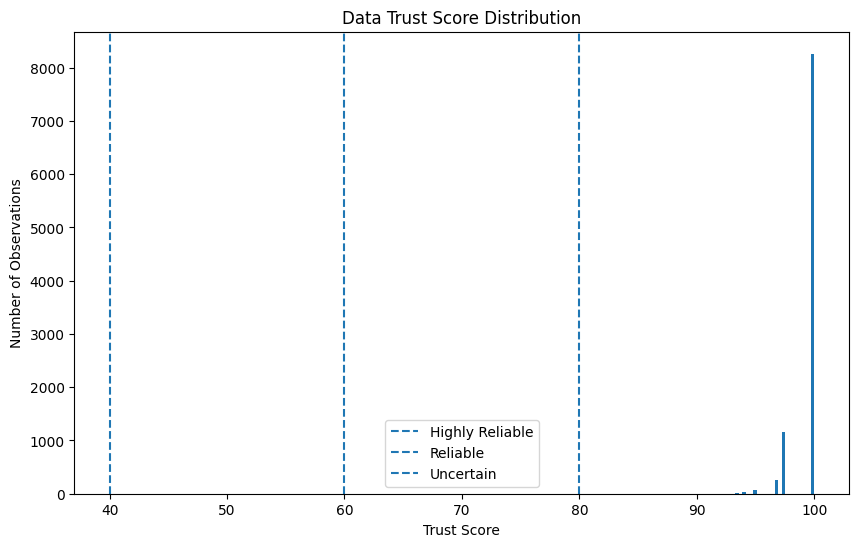

In [26]:
# %%
plt.figure(figsize=(10, 6))

plt.hist(
    df["Trust_Score"],
    bins=30
)

plt.axvline(
    80,
    linestyle="--",
    label="Highly Reliable"
)

plt.axvline(
    60,
    linestyle="--",
    label="Reliable"
)

plt.axvline(
    40,
    linestyle="--",
    label="Uncertain"
)

plt.xlabel(
    "Trust Score"
)

plt.ylabel(
    "Number of Observations"
)

plt.title(
    "Data Trust Score Distribution"
)

plt.legend()

plt.show()

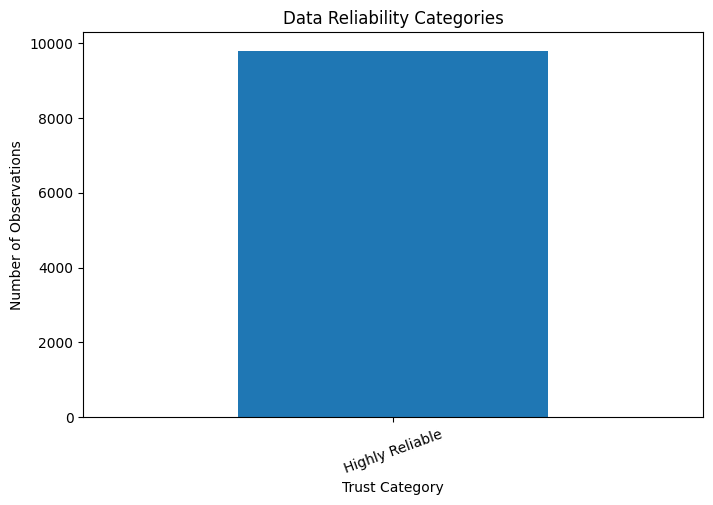

In [27]:
# %%
category_counts = (
    df["Trust_Category"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

category_counts.plot(
    kind="bar"
)

plt.xlabel(
    "Trust Category"
)

plt.ylabel(
    "Number of Observations"
)

plt.title(
    "Data Reliability Categories"
)

plt.xticks(
    rotation=20
)

plt.show()

In [28]:
# %%
station_summary = (
    df.groupby("Station_ID")
    .agg(
        Average_Trust=(
            "Trust_Score",
            "mean"
        ),

        Minimum_Trust=(
            "Trust_Score",
            "min"
        ),

        Maximum_Trust=(
            "Trust_Score",
            "max"
        ),

        Observations=(
            "Trust_Score",
            "count"
        )
    )
    .sort_values(
        "Average_Trust"
    )
)

station_summary

,Average_Trust,Minimum_Trust,Maximum_Trust,Observations
Station_ID,,,,
STN-04,99.513265,90.833333,100.0,2450
STN-03,99.537755,91.666667,100.0,2450
STN-02,99.558163,93.333333,100.0,2450
STN-01,99.589116,91.666667,100.0,2450


In [29]:
# %%
OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "scored_train.csv"
)

df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(
    "✅ Scored dataset saved:"
)

print(
    OUTPUT_PATH
)

✅ Scored dataset saved:
D:\XO06_DS02\outputs\scored_train.csv


In [30]:
# %%
print("=" * 55)
print("          DATA TRUST ENGINE SUMMARY")
print("=" * 55)

print(
    "Total observations:",
    len(df)
)

print(
    "Average Trust Score:",
    round(
        df["Trust_Score"].mean(),
        2
    )
)

print(
    "Low Trust observations:",
    (
        df["Trust_Category"]
        == "Low Trust"
    ).sum()
)

print(
    "Uncertain observations:",
    (
        df["Trust_Category"]
        == "Uncertain"
    ).sum()
)

print(
    "Affected observations:",
    (
        df["Affected_Sensors"]
        != "None"
    ).sum()
)

print(
    "Output file:",
    OUTPUT_PATH
)

print("=" * 55)

          DATA TRUST ENGINE SUMMARY
Total observations: 9800
Average Trust Score: 99.55
Low Trust observations: 0
Uncertain observations: 0
Affected observations: 294
Output file: D:\XO06_DS02\outputs\scored_train.csv
